In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the TF-IDF train/test data saved in feature engineering
X_train = sp.load_npz('saved_models/X_train.npz')
X_test  = sp.load_npz('saved_models/X_test.npz')
y_train = np.load('saved_models/y_train.npy')
y_test  = np.load('saved_models/y_test.npy')

print("✅ Train/Test data loaded!")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

✅ Train/Test data loaded!
X_train shape : (35378, 10000)
X_test shape  : (8845, 10000)
y_train shape : (35378,)
y_test shape  : (8845,)


In [3]:
# Train Logistic Regression
# max_iter=1000 ensures model has enough iterations to converge
# C=1.0 is regularization strength (default)
# solver='lbfgs' is efficient for large datasets

print("Training Logistic Regression model...")
print("Please wait...")

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)

print("✅ Model trained successfully!")

Training Logistic Regression model...
Please wait...
✅ Model trained successfully!


In [4]:
# Predict on test set
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print("✅ Predictions made!")
print(f"\nSample predictions (first 10):")
print(f"Predicted : {y_pred[:10]}")
print(f"Actual    : {y_test[:10]}")

✅ Predictions made!

Sample predictions (first 10):
Predicted : [0 0 0 0 1 0 0 0 1 0]
Actual    : [0 0 0 0 1 0 0 0 1 0]


In [5]:
# Calculate all metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("   LOGISTIC REGRESSION — EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 50)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fake News', 'Real News']))

   LOGISTIC REGRESSION — EVALUATION RESULTS
  Accuracy  : 0.9943  (99.43%)
  Precision : 0.9921
  Recall    : 0.9963
  F1-Score  : 0.9942
  ROC-AUC   : 0.9998

Detailed Classification Report:
              precision    recall  f1-score   support

   Fake News       1.00      0.99      0.99      4562
   Real News       0.99      1.00      0.99      4283

    accuracy                           0.99      8845
   macro avg       0.99      0.99      0.99      8845
weighted avg       0.99      0.99      0.99      8845



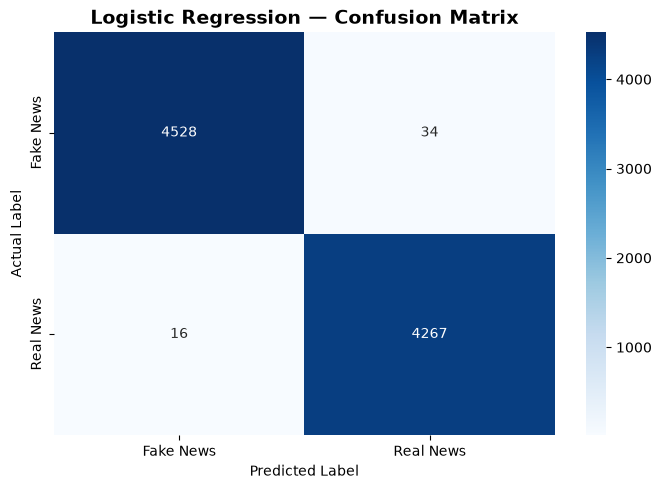


Confusion Matrix Breakdown:
  True Positives  (Real correctly identified) : 4,267
  True Negatives  (Fake correctly identified) : 4,528
  False Positives (Fake wrongly called Real)  : 34
  False Negatives (Real wrongly called Fake)  : 16


In [6]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake News', 'Real News'],
    yticklabels=['Fake News', 'Real News']
)
plt.title('Logistic Regression — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

# Explain the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Positives  (Real correctly identified) : {tp:,}")
print(f"  True Negatives  (Fake correctly identified) : {tn:,}")
print(f"  False Positives (Fake wrongly called Real)  : {fp:,}")
print(f"  False Negatives (Real wrongly called Fake)  : {fn:,}")

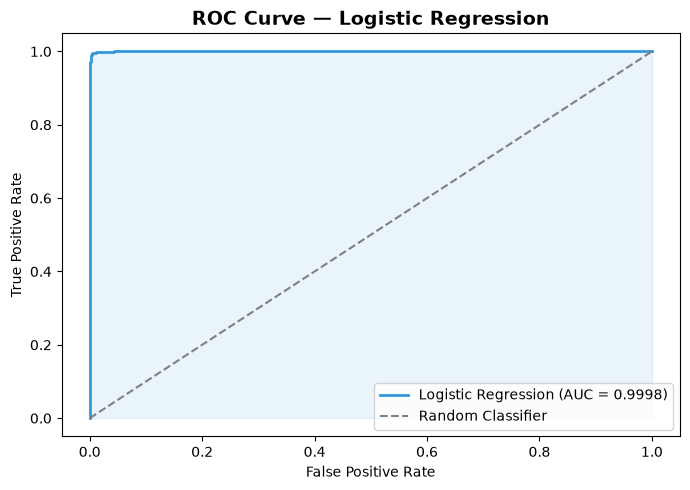

✅ ROC Curve saved!


In [7]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db',
         linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray',
         linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
plt.title('ROC Curve — Logistic Regression',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('lr_roc_curve.png', dpi=150)
plt.show()

print("✅ ROC Curve saved!")

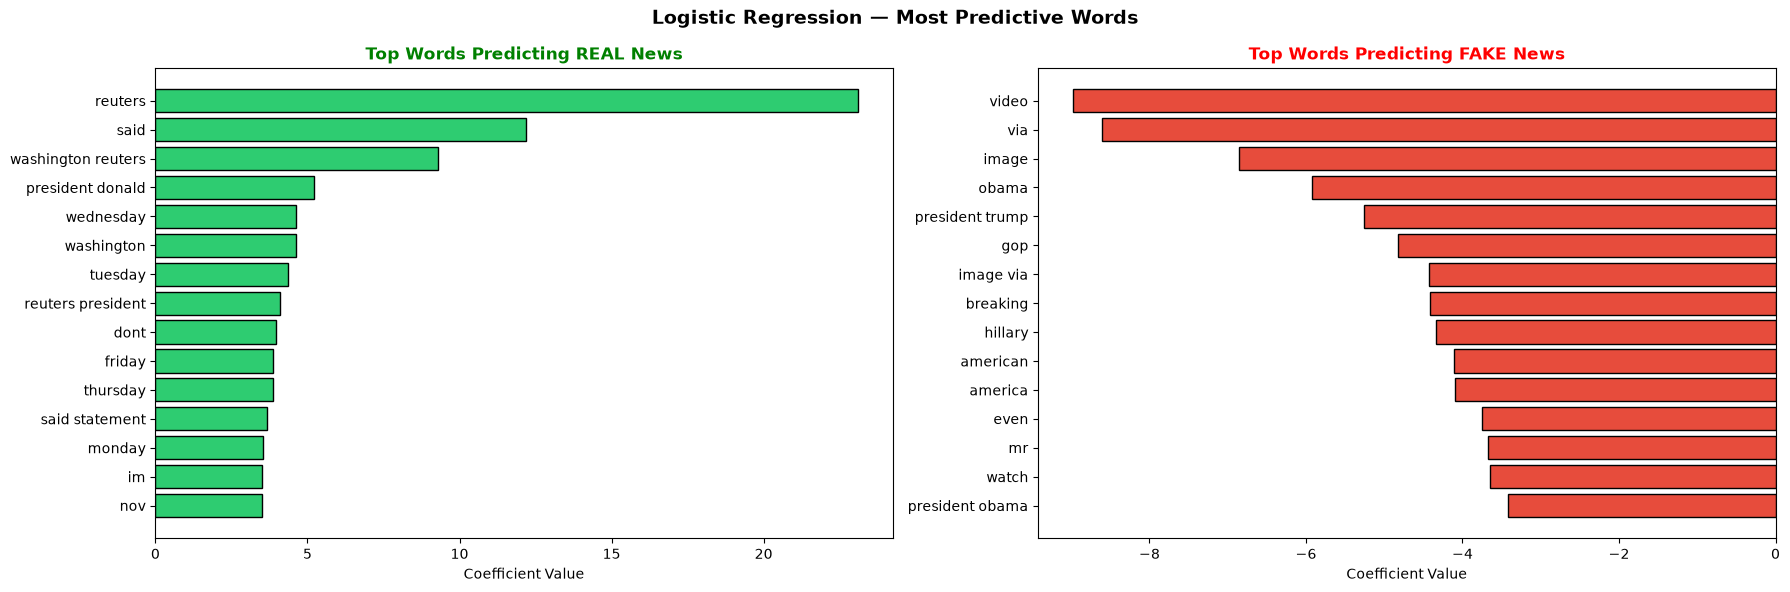

✅ Top predictive words chart saved!


In [8]:
# Load vectorizer to get feature names
tfidf = pickle.load(open('saved_models/tfidf_vectorizer.pkl', 'rb'))
feature_names = tfidf.get_feature_names_out()

# Get model coefficients
coefficients = lr_model.coef_[0]

# Top 15 words predicting REAL news (positive coefficients)
top_real_idx = coefficients.argsort()[-15:][::-1]
# Top 15 words predicting FAKE news (negative coefficients)
top_fake_idx = coefficients.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Real news words
real_words  = [feature_names[i] for i in top_real_idx]
real_coefs  = [coefficients[i] for i in top_real_idx]
axes[0].barh(real_words[::-1], real_coefs[::-1],
             color='#2ecc71', edgecolor='black')
axes[0].set_title('Top Words Predicting REAL News',
                   fontsize=12, fontweight='bold', color='green')
axes[0].set_xlabel('Coefficient Value')

# Fake news words
fake_words  = [feature_names[i] for i in top_fake_idx]
fake_coefs  = [coefficients[i] for i in top_fake_idx]
axes[1].barh(fake_words[::-1], fake_coefs[::-1],
             color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Words Predicting FAKE News',
                   fontsize=12, fontweight='bold', color='red')
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Most Predictive Words',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_top_words.png', dpi=150)
plt.show()

print("✅ Top predictive words chart saved!")

In [9]:
# Save trained model
pickle.dump(lr_model,
            open('saved_models/lr_model.pkl', 'wb'))

print("✅ Logistic Regression model saved!")
print("\n📁 Files saved in saved_models/:")
print("   - lr_model.pkl")

✅ Logistic Regression model saved!

📁 Files saved in saved_models/:
   - lr_model.pkl


In [10]:
print("=" * 55)
print("   ML MODEL SUMMARY — Logistic Regression (Hansaja)")
print("=" * 55)
print(f"""
🤖 MODEL
   Algorithm     : Logistic Regression
   Feature Input : TF-IDF (10,000 features)
   Training Size : {X_train.shape[0]:,} samples
   Testing Size  : {X_test.shape[0]:,} samples

📊 PERFORMANCE
   Accuracy      : {accuracy*100:.2f}%
   Precision     : {precision:.4f}
   Recall        : {recall:.4f}
   F1-Score      : {f1:.4f}
   ROC-AUC       : {roc_auc:.4f}

💡 WHY LOGISTIC REGRESSION?
   Logistic Regression is highly interpretable,
   fast to train, and works excellently with
   TF-IDF sparse matrices. It provides probability
   scores making it ideal for classification tasks
   like fake news detection.

📁 SAVED FILES
   ✅ lr_model.pkl
   ✅ lr_confusion_matrix.png
   ✅ lr_roc_curve.png
   ✅ lr_top_words.png
""")

   ML MODEL SUMMARY — Logistic Regression (Hansaja)

🤖 MODEL
   Algorithm     : Logistic Regression
   Feature Input : TF-IDF (10,000 features)
   Training Size : 35,378 samples
   Testing Size  : 8,845 samples

📊 PERFORMANCE
   Accuracy      : 99.43%
   Precision     : 0.9921
   Recall        : 0.9963
   F1-Score      : 0.9942
   ROC-AUC       : 0.9998

💡 WHY LOGISTIC REGRESSION?
   Logistic Regression is highly interpretable,
   fast to train, and works excellently with
   TF-IDF sparse matrices. It provides probability
   scores making it ideal for classification tasks
   like fake news detection.

📁 SAVED FILES
   ✅ lr_model.pkl
   ✅ lr_confusion_matrix.png
   ✅ lr_roc_curve.png
   ✅ lr_top_words.png

